In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb


In [ ]:
RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)

plots_dir = "../plots"
os.makedirs(plots_dir, exist_ok=True)

# Load Best XGBoost model

In [ ]:
xgb_json_path = "../models/XGB/best_xgb_1to10_all.json"

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(xgb_json_path)

print("Loaded XGBoost model from:", xgb_json_path)


Loaded XGBoost model from: ../models/XGB/best_xgb_1to10_all.json


# Load data

In [ ]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_downsampled_1to5_with_merchants.csv')
df_val   = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test  = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

df_train_xgb = df_train.copy()
df_val_xgb   = df_val.copy()
df_test_xgb  = df_test.copy()


# Data Processing

In [8]:

print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'dayOfWeekName', 'transaction_sequence',
    'isFlaggedFraud', 'typeHighValueFlag', 'amountBucket',
]

for col in categorical_cols:
    # Combine categories from train/val/test to avoid unseen categories
    combined_cats = pd.Series(
        pd.concat([df_train_xgb[col], df_val_xgb[col], df_test_xgb[col]], axis=0)
        .dropna()
        .unique()
    )
    categories = sorted(combined_cats.unique())

    df_train_xgb[col] = pd.Categorical(df_train_xgb[col], categories=categories)
    df_val_xgb[col]   = pd.Categorical(df_val_xgb[col],   categories=categories)
    df_test_xgb[col]  = pd.Categorical(df_test_xgb[col],  categories=categories)


Converting categorical columns ...


In [9]:

# Same selected_features as in your XGBoost section
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 'dayOfWeek', 'amount', 
    'oldbalanceOrg', 'oldbalanceDest',
    'amount_to_oldbalanceOrg',
     
    # account-level features
    'meanSent', 
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived',  'numReceived', 
    'stdReceived', 'meanReceived', 
    'maxAmountReceived', 'stdAmountReceived', 'std_to_mean_ratio', 
    'avgAmountToDest', 
    'pctForwarded24h', 'pairFrequency', 'pctUniqueDest', 'pctUniqueOrig', 

    # transaction pattern features 
    'transaction_sequence', 'sequence_frequency', 'transactionRecency',
    'typeHighValueFlag', 'is_early_transaction',  'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer',
    'is_cashin_transfer_cashout', 'is_transfer_transfer', 'is_first_transfer',
    'is_cashin_cashout', 

    # centrality features
    'sender_btwn', 'receiver_btwn', 'btwn_diff', 
    'sender_outdeg_amt', 'sender_indeg_amt', 'receiver_outdeg_amt',
    'receiver_indeg_amt',
    'sender_outdeg_cnt', 'sender_indeg_cnt', 'receiver_outdeg_cnt',
    'receiver_indeg_cnt', 
    'outdeg_amt_diff', 'indeg_amt_diff',
    'outdeg_cnt_diff', 'indeg_cnt_diff' 
]


In [10]:

print("Processing validation set ...")
Xval_xgb  = df_val_xgb[selected_features].copy()
yval_xgb  = df_val_xgb["isFraud"].astype(int)

print("Xval_xgb shape:", Xval_xgb.shape)


Processing validation set ...
Xval_xgb shape: (954393, 54)


# SHAP for XGBoost

In [ ]:
# Sample a subset of validation data for SHAP (for speed)
n = len(Xval_xgb)
sample_n = min(100, n)
idx = rng.choice(np.arange(n), size=sample_n, replace=False)

Xval_xgb_sample = Xval_xgb.iloc[idx].copy()
xgb_feature_names = Xval_xgb_sample.columns.tolist()

# Keep categorical dtypes & remove unused categories
for c in Xval_xgb_sample.select_dtypes(include='category').columns:
    Xval_xgb_sample[c] = Xval_xgb_sample[c].cat.remove_unused_categories()

dm = xgb.DMatrix(Xval_xgb_sample, enable_categorical=True)
booster = xgb_model.get_booster()

shap_values_xgb_full = booster.predict(dm, pred_contribs=True) 
shap_values_xgb = shap_values_xgb_full[:, :-1]  # drop bias term


## SHAP plots (global interpretability)

### Beeswarm plot

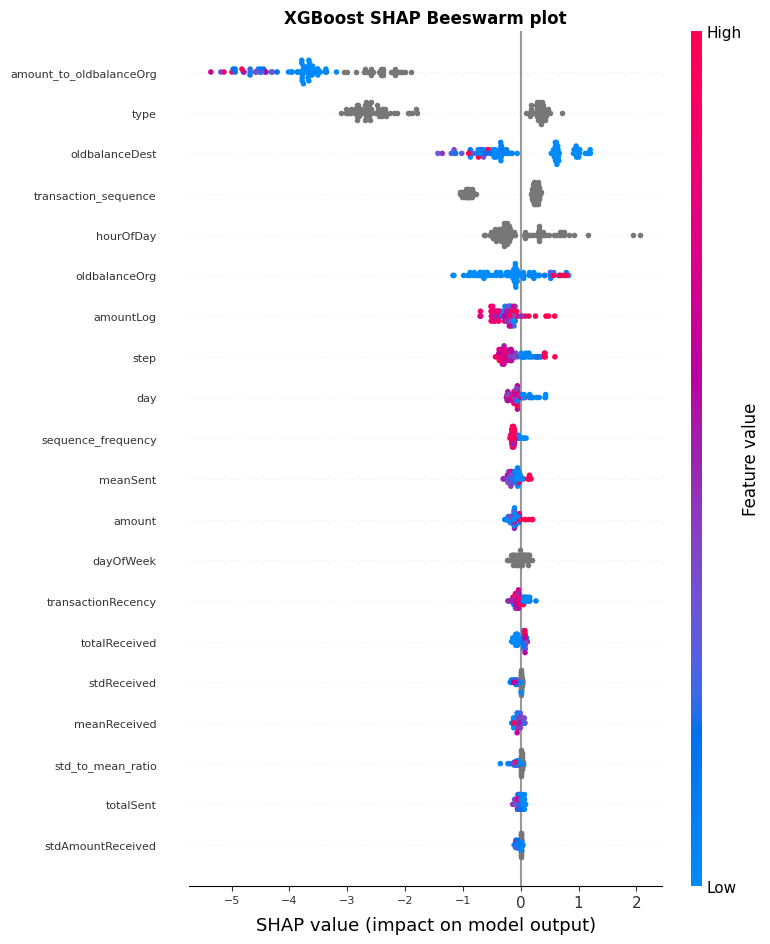

✓ XGBoost SHAP beeswarm plot saved: xgb_shap_beeswarm.png


In [20]:
plt.figure(figsize=(10, 6))
plt.title("XGBoost SHAP Beeswarm plot", fontsize=12, fontweight="bold")
shap.summary_plot(
    shap_values_xgb,
    Xval_xgb_sample,
    feature_names=xgb_feature_names,
    show=False
)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(plots_dir, "xgb_shap_beeswarm.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("✓ XGBoost SHAP beeswarm plot saved: xgb_shap_beeswarm.png")


### Bar plot

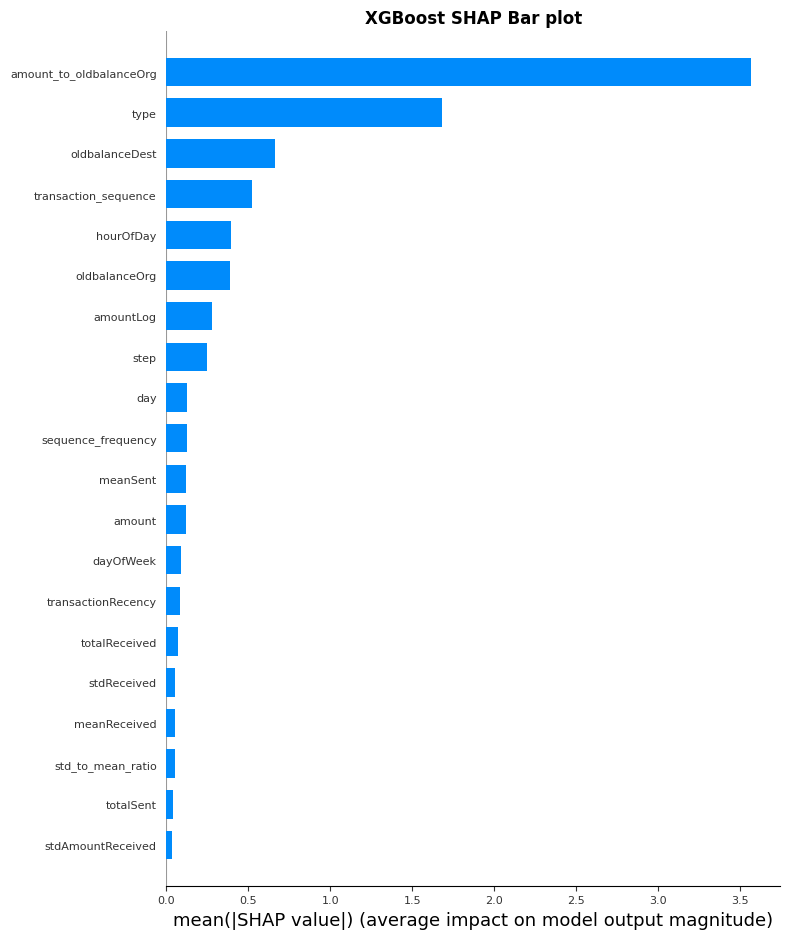

✓ XGBoost SHAP bar plot saved: xgb_shap_bar.png


In [21]:
# Bar plot (mean |SHAP| per feature)
plt.figure(figsize=(8, 5))
plt.title("XGBoost SHAP Bar plot", fontsize=12, fontweight="bold")
shap.summary_plot(
    shap_values_xgb,
    Xval_xgb_sample,
    feature_names=xgb_feature_names,
    plot_type="bar",
    show=False
)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(plots_dir, "xgb_shap_bar.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("✓ XGBoost SHAP bar plot saved: xgb_shap_bar.png")


Chosen fraud index in validation set: 950400
True label: 1
Predicted fraud probability: 0.9999


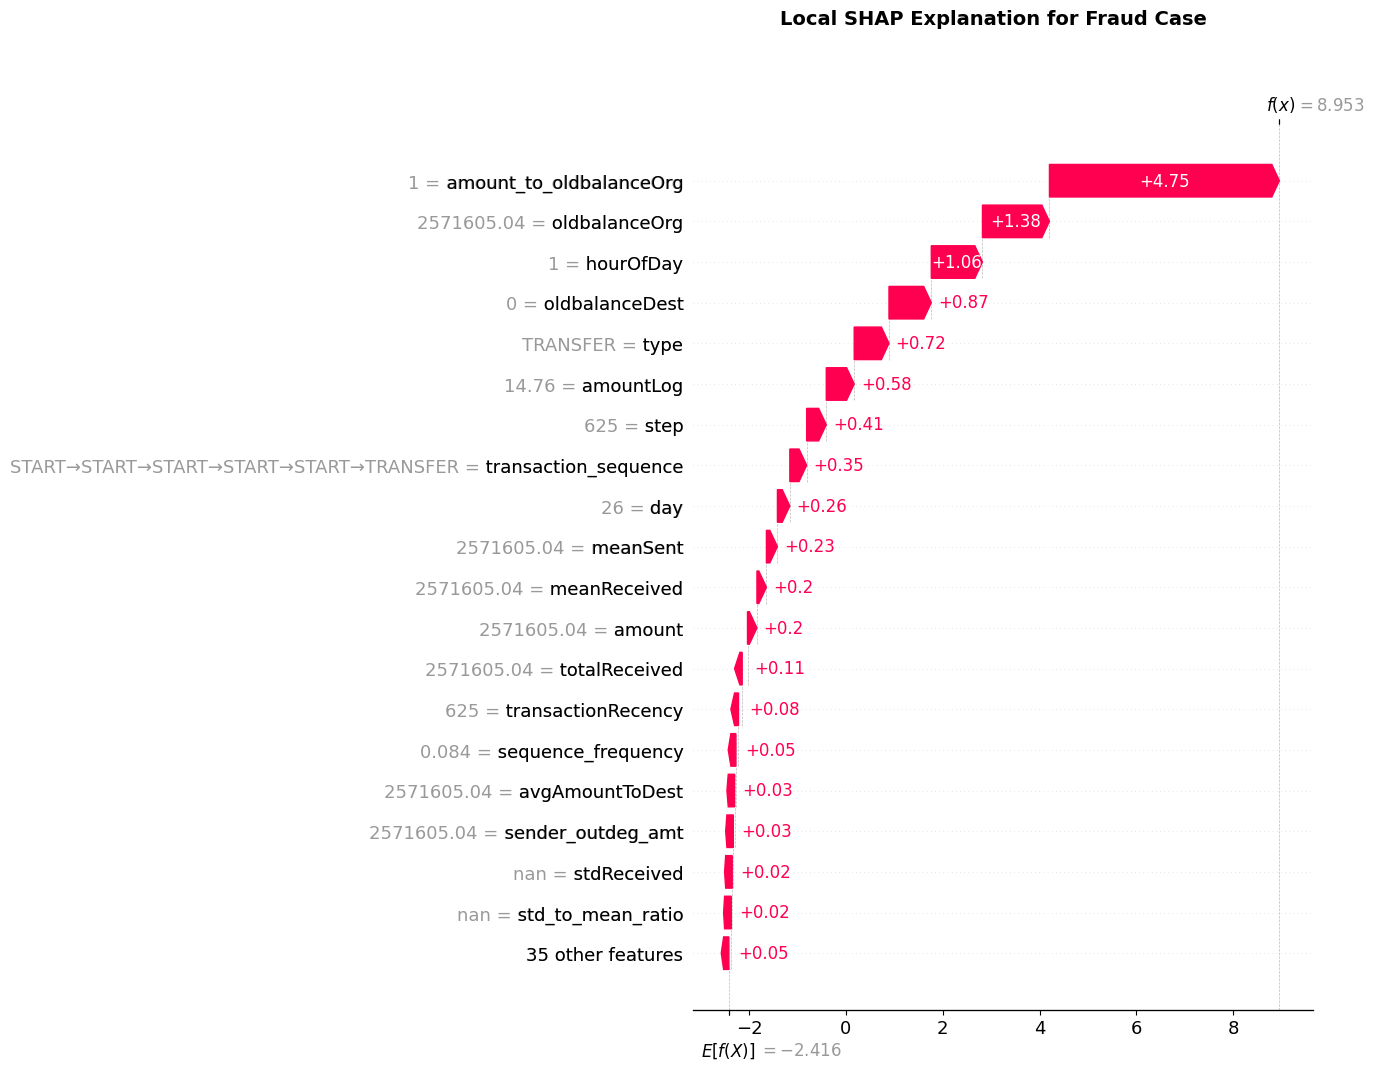

✓ Saved local fraud explanation waterfall plot to: ../plots/xgb_shap_waterfall_fraud_example.png


✓ Saved local fraud force plot to: ../plots/xgb_shap_force_fraud_example.html


In [25]:
from shap.plots import _waterfall

# getting  XGBoost predicted probabilities on the full validation set
p_xgb_val_full = xgb_model.predict_proba(Xval_xgb)[:, 1]

# find all fraud indices in the full validation set
fraud_indices_all = np.where(yval_xgb.values == 1)[0]

if len(fraud_indices_all) == 0:
    print("No fraud cases in the entire validation set! Cannot explain a fraud case.")
else:
    # among fraud cases, pick the one with the highest predicted fraud probability
    fraud_idx_best = fraud_indices_all[np.argmax(p_xgb_val_full[fraud_indices_all])]
    print(f"Chosen fraud index in validation set: {fraud_idx_best}")
    print(f"True label: {yval_xgb.iloc[fraud_idx_best]}")
    print(f"Predicted fraud probability: {p_xgb_val_full[fraud_idx_best]:.4f}")

    X_row = Xval_xgb.iloc[[fraud_idx_best]].copy() 

    # ensure categorical dtypes + remove unused categories
    for c in X_row.select_dtypes(include='category').columns:
        X_row[c] = X_row[c].cat.remove_unused_categories()

    # 5) build a dmatrix for this single row and get SHAP values
    drow = xgb.DMatrix(X_row, enable_categorical=True)
    booster = xgb_model.get_booster()

    shap_values_row_full = booster.predict(drow, pred_contribs=True)  # shape: (1, n_features + 1)
    shap_values_row = shap_values_row_full[0, :-1]  # feature SHAP values
    base_value = shap_values_row_full[0, -1]        # bias term
    feature_names = X_row.columns.tolist()
    feature_values = X_row.iloc[0, :]

    expl = shap.Explanation(
        values=shap_values_row,
        base_values=base_value,
        data=feature_values,
        feature_names=feature_names
    )


    # waterfall
    fig, ax = plt.subplots(figsize=(8, 6))

    # Use the legacy matplotlib waterfall, NOT shap.plots.waterfall
    try:
        # Many recent SHAP versions
        _waterfall.waterfall(expl, max_display=20, show=False, ax=ax)
    except TypeError:
    # Fallback for slightly older versions (no ax argument)
        _waterfall.waterfall(expl, max_display=20, show=False)

    fig.suptitle("Local SHAP Explanation for Fraud Case", fontsize=14, fontweight="bold")

    png_path = os.path.join(plots_dir, "xgb_shap_waterfall_fraud_example.png")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ Saved local fraud explanation waterfall plot to:", png_path)

    # interactive force plot as HTML
    shap.initjs()
    force_plot = shap.force_plot(
        base_value,
        shap_values_row,
        feature_values,
        feature_names=feature_names
    )
    html_path = os.path.join(plots_dir, "xgb_shap_force_fraud_example.html")
    shap.save_html(html_path, force_plot)
    print("✓ Saved local fraud force plot to:", html_path)
